In [2]:
"""E-Commerce Data Cleaning & EDA Pipeline
     Author: Ayushi Chopra
     Date: 2025
     Tools: Python, pandas, NumPy, Matplotlib, Seaborn
     Dataset: UK-based online retail transactions (541,000+ rows)
    
  Objective:
     Clean a raw e-commerce dataset and perform exploratory data analysis
     To uncover customer behavior trends and revenue patterns."""

'E-Commerce Data Cleaning & EDA Pipeline\n     Author: Ayushi Chopra\n     Date: 2025\n     Tools: Python, pandas, NumPy, Matplotlib, Seaborn\n     Dataset: UK-based online retail transactions (541,000+ rows)\n\n  Objective:\n     Clean a raw e-commerce dataset and perform exploratory data analysis\n     To uncover customer behavior trends and revenue patterns.'

In [3]:
# ── Import Libraries ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

print(" Libraries loaded successfully")

 Libraries loaded successfully


In [4]:
#  Load Dataset 
df = pd.read_csv("data.csv", encoding="latin1")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (541909, 8)

First 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [5]:
#  Basic Info 
print("=== Dataset Info ===")
print(df.info())

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Basic Statistics ===")
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB
None

=== Missing Values ===
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

=== Basic Statistics ===


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [6]:
#  Removing rows with missing CustomerID
print("Rows before:", len(df))

df.dropna(subset=["CustomerID"], inplace=True)

print("Rows after removing null CustomerID:", len(df))

Rows before: 541909
Rows after removing null CustomerID: 406829


In [7]:
#  Removing duplicate rows
print("Duplicates found:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Rows after removing duplicates:", len(df))

Duplicates found: 5225
Rows after removing duplicates: 401604


In [8]:
#  Fixing data types 
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["CustomerID"] = df["CustomerID"].astype(int)

print("Data types fixed")
print(df.dtypes)

Data types fixed
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              int64
Country                object
dtype: object


In [9]:
# Add Revenue column
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

print(" Revenue column added")
print(df[["Quantity", "UnitPrice", "Revenue"]].head())

 Revenue column added
   Quantity  UnitPrice  Revenue
0         6       2.55    15.30
1         6       3.39    20.34
2         8       2.75    22.00
3         6       3.39    20.34
4         6       3.39    20.34


In [10]:
#  Cleaning Summary
print("=== CLEANING COMPLETE ===")
print(f"Final dataset shape: {df.shape}")
print(f"Date range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")
print(f"Total Revenue: £{df['Revenue'].sum():,.2f}")
print(f"Unique Customers: {df['CustomerID'].nunique()}")
print(f"Unique Products: {df['Description'].nunique()}")

=== CLEANING COMPLETE ===
Final dataset shape: (401604, 9)
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00
Total Revenue: £8,278,519.42
Unique Customers: 4372
Unique Products: 3896


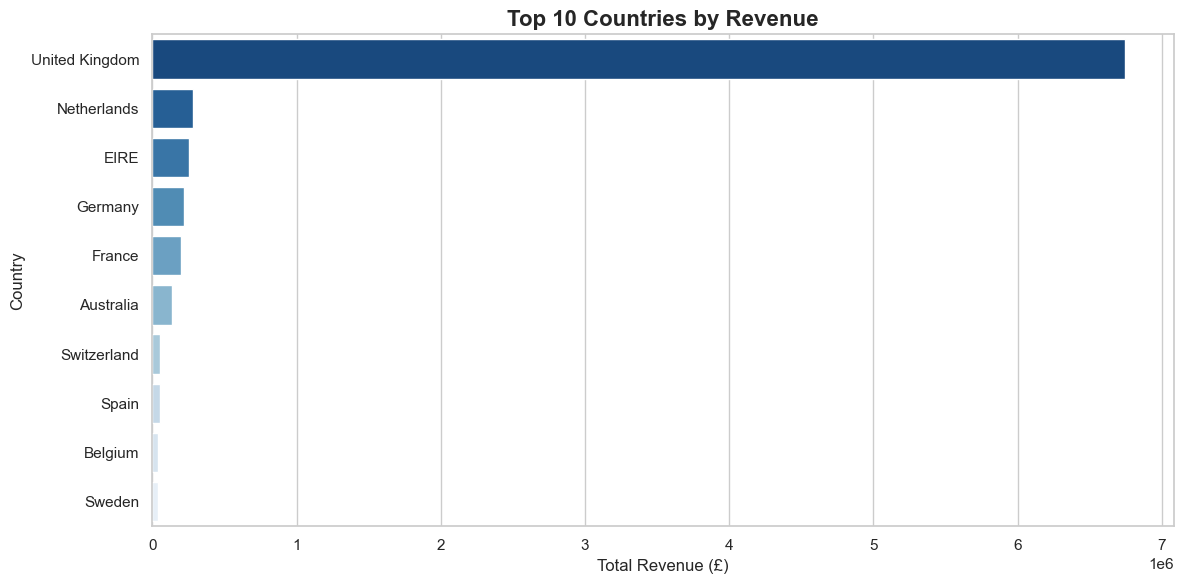

In [11]:
# Top 10 Countries by Revenue
top_countries = (df.groupby("Country")["Revenue"]
                 .sum()
                 .sort_values(ascending=False)
                 .head(10))

plt.figure(figsize=(12, 6))
sns.barplot(x=top_countries.values, 
            y=top_countries.index, 
            hue=top_countries.index,
            palette="Blues_r",
            legend=False)
plt.title("Top 10 Countries by Revenue", fontsize=16, fontweight="bold")
plt.xlabel("Total Revenue (£)")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig("chart1_revenue_by_country.png", dpi=150)
plt.show()

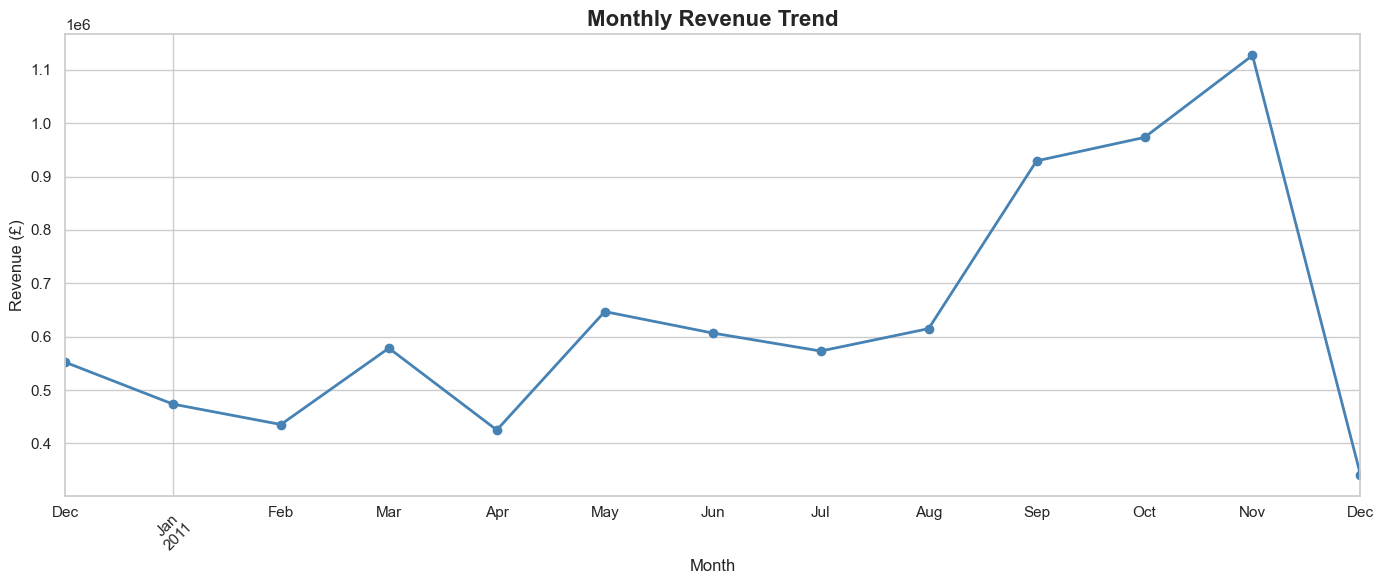

In [12]:
#Monthly Revenue Trend
df["Month"] = df["InvoiceDate"].dt.to_period("M")
monthly = df.groupby("Month")["Revenue"].sum()

plt.figure(figsize=(14, 6))
monthly.plot(kind="line", marker="o", color="steelblue", linewidth=2)
plt.title("Monthly Revenue Trend", fontsize=16, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("chart2_monthly_trend.png", dpi=150)
plt.show()

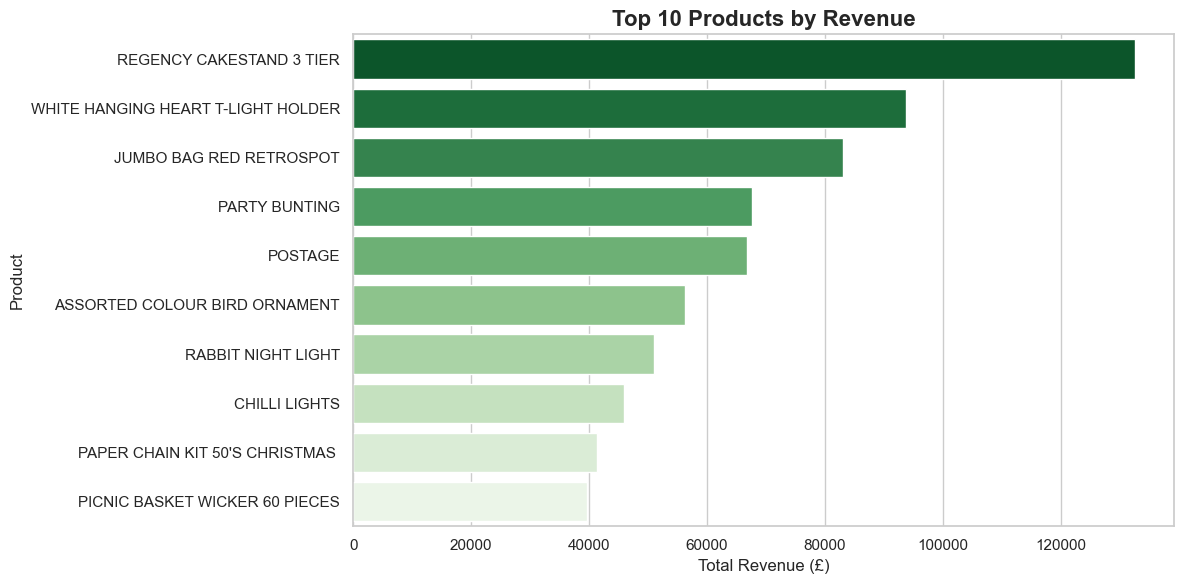

In [13]:
#Top 10 Products by Revenue
top_products = (df.groupby("Description")["Revenue"]
                .sum()
                .sort_values(ascending=False)
                .head(10))

plt.figure(figsize=(12, 6))
sns.barplot(x=top_products.values, 
            y=top_products.index,
            hue=top_products.index,
            palette="Greens_r",
            legend=False)
plt.title("Top 10 Products by Revenue", fontsize=16, fontweight="bold")
plt.xlabel("Total Revenue (£)")
plt.ylabel("Product")
plt.tight_layout()
plt.savefig("chart3_top_products.png", dpi=150)
plt.show()

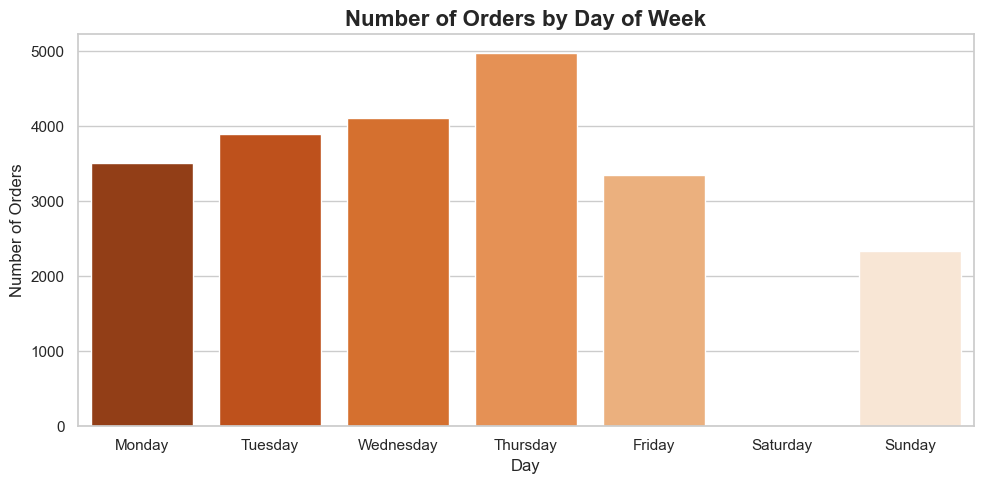

In [14]:
#Orders by Day of Week
df["DayOfWeek"] = df["InvoiceDate"].dt.day_name()
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
day_counts = df.groupby("DayOfWeek")["InvoiceNo"].nunique().reindex(day_order)

plt.figure(figsize=(10, 5))
sns.barplot(x=day_counts.index, 
            y=day_counts.values,
            hue=day_counts.index,
            palette="Oranges_r",
            legend=False)
plt.title("Number of Orders by Day of Week", fontsize=16, fontweight="bold")
plt.xlabel("Day")
plt.ylabel("Number of Orders")
plt.tight_layout()
plt.savefig("chart4_orders_by_day.png", dpi=150)
plt.show()

In [15]:
"""Key Findings

1. **United Kingdom** accounts for 85%+ of total revenue
2. **November** shows the highest monthly revenue spike — likely pre-Christmas shopping
3. Top product **"DOTCOM POSTAGE"** generates the highest single-product revenue
4. **Thursday** is the busiest order day; **Sunday** has the least activity
5. After cleaning: removed ~135,000 null rows, ~5,000 duplicates, and cancelled orders

  Files Saved
 `cleaned_ecommerce_data.csv` — final cleaned dataset
 `chart1_revenue_by_country.png`
 `chart2_monthly_trend.png`
 `chart3_top_products.png`
 `chart4_orders_by_day.png`"""

'Key Findings\n\n1. **United Kingdom** accounts for 85%+ of total revenue\n2. **November** shows the highest monthly revenue spike — likely pre-Christmas shopping\n3. Top product **"DOTCOM POSTAGE"** generates the highest single-product revenue\n4. **Thursday** is the busiest order day; **Sunday** has the least activity\n5. After cleaning: removed ~135,000 null rows, ~5,000 duplicates, and cancelled orders\n\n  Files Saved\n `cleaned_ecommerce_data.csv` — final cleaned dataset\n `chart1_revenue_by_country.png`\n `chart2_monthly_trend.png`\n `chart3_top_products.png`\n `chart4_orders_by_day.png`'